<a href="https://colab.research.google.com/github/jellybbie/study/blob/project1/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [7]:
import pandas as pd

excel_file_path = '/content/screening(2025)-4.xlsx'
df = pd.read_excel(excel_file_path)
display(df.head())

,96well Name,Location in 96well,Strain,IAA production,Cytokinin production,ACC deaminase activity,Phosphate solubilization,Nitrogen fixation
0,콩 내생분리균 1-1,A1,RMR-1,1.1787,0.1084,0.0488,0.4534,0.1425
1,콩 내생분리균 1-1,A2,RMR-2,1.0249,0.1206,0.0491,0.6858,0.1628
2,콩 내생분리균 1-1,A3,RMR-3,0.9659,0.1164,0.0486,0.7367,0.1588
3,콩 내생분리균 1-1,A4,RMR-4,1.2435,0.1166,0.0469,0.6707,0.1565
4,콩 내생분리균 1-1,A5,RMR-5,0.9413,0.1391,0.0857,0.7560,0.2239


In [8]:
import numpy as np

# Define the characteristic columns
characteristic_cols = [
    'IAA production',
    'Cytokinin production',
    'ACC deaminase activity',
    'Phosphate solubilization',
    'Nitrogen fixation'
]

# Check for duplicate strains in the 'Strain' column
duplicate_strains_count = df['Strain'].duplicated().sum()

if duplicate_strains_count > 0:
    print(f"Found {duplicate_strains_count} duplicate strain entries. Aggregating data by taking the mean for each characteristic.")
    # Group by 'Strain' and calculate the mean for the characteristic columns
    processed_df = df.groupby('Strain')[characteristic_cols].mean().reset_index()
else:
    print("No duplicate strains found. Using the original DataFrame for analysis.")
    processed_df = df.copy()

print(f"\nTotal unique or aggregated strains for analysis: {len(processed_df)}")


Found 119 duplicate strain entries. Aggregating data by taking the mean for each characteristic.

Total unique or aggregated strains for analysis: 1688


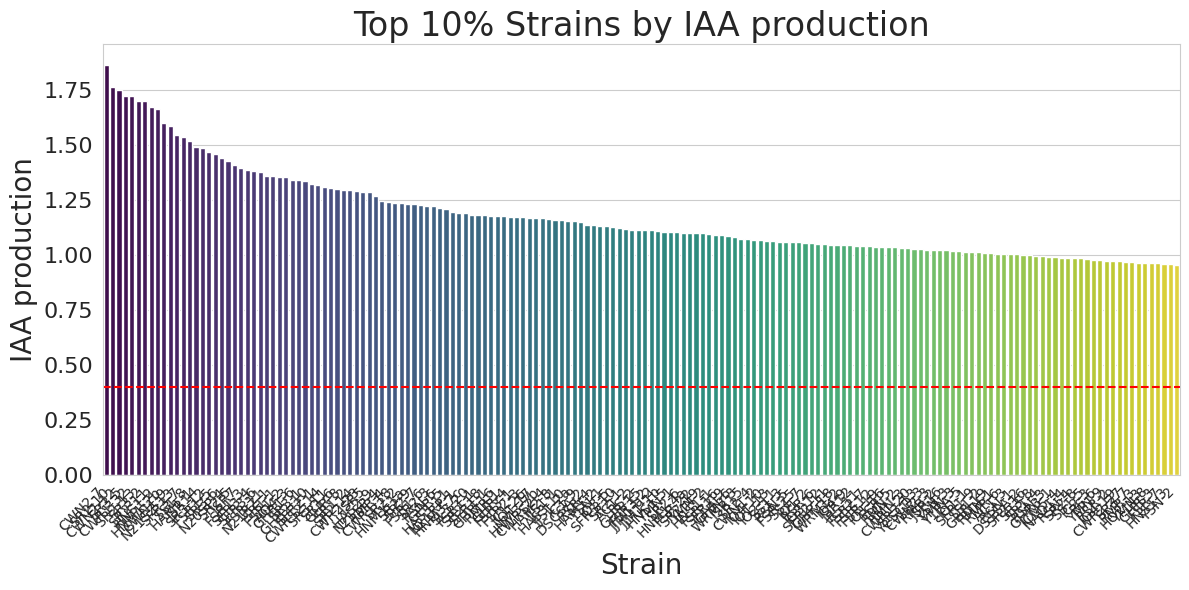

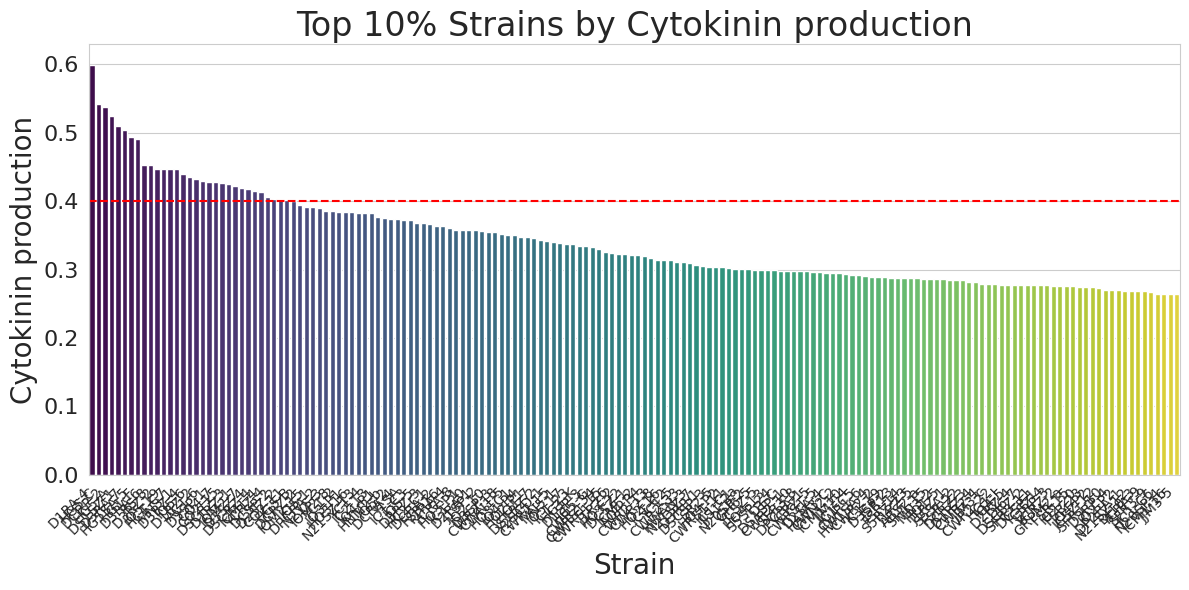

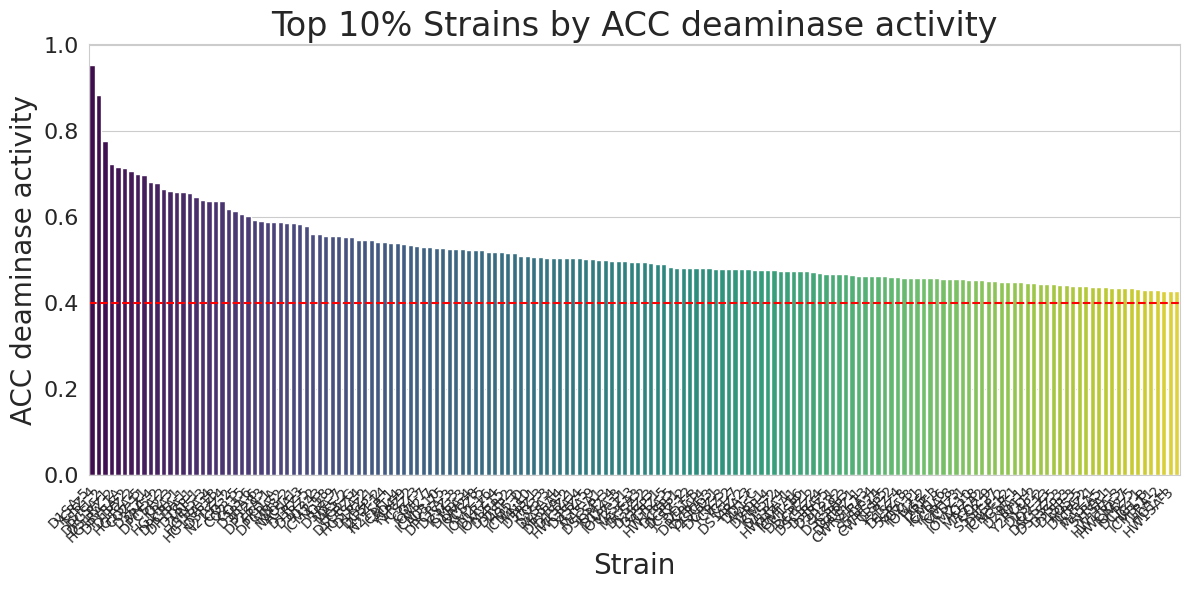

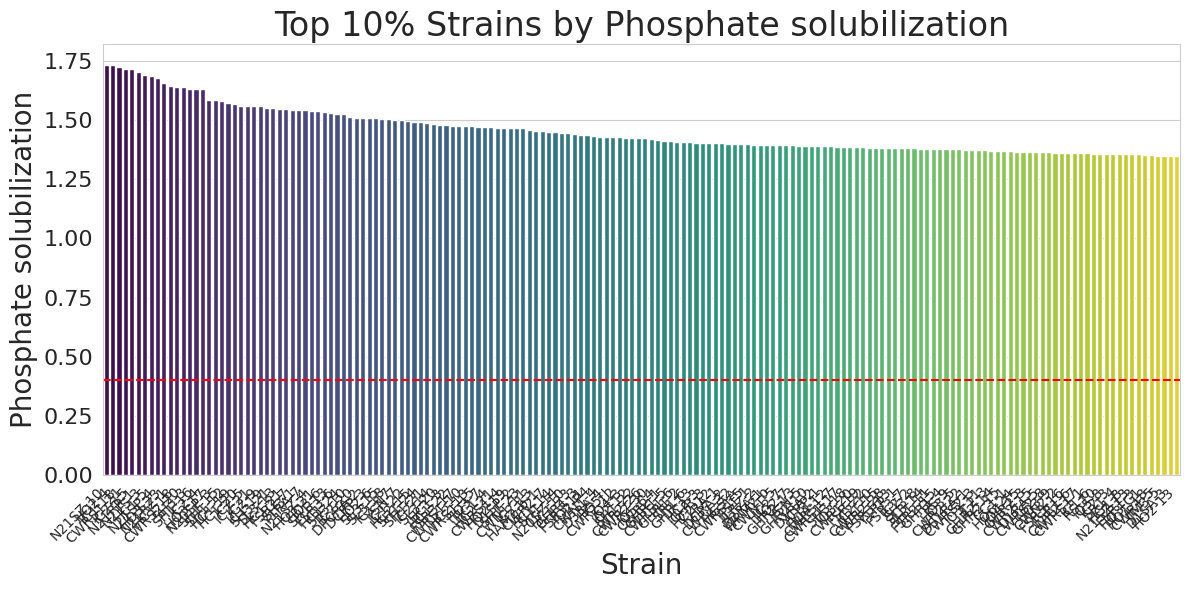

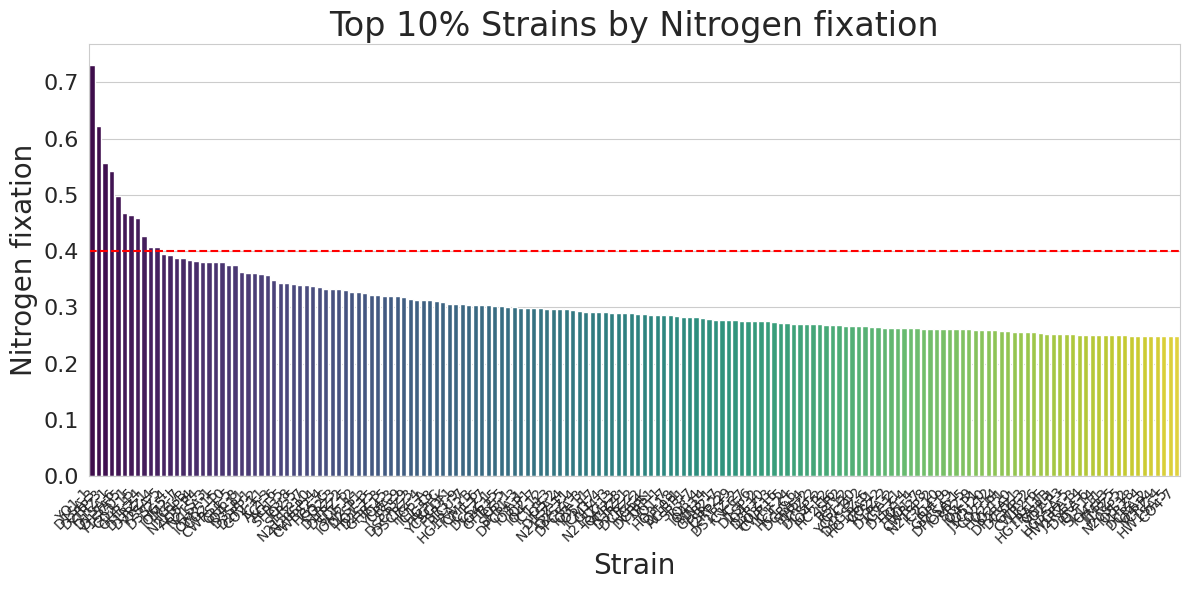

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming characteristic_cols and processed_df are already defined from previous steps

for col in characteristic_cols:
    # Calculate the number of top strains (10%)
    num_top_strains = max(1, int(len(processed_df) * 0.10))

    # Sort by the current characteristic in descending order and select the top strains
    top_strains = processed_df.sort_values(by=col, ascending=False).head(num_top_strains)

    # Create a bar plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Strain', y=col, data=top_strains, palette='viridis', hue='Strain', legend=False)
    plt.title(f'Top 10% Strains by {col}', fontsize=24)
    plt.xlabel('Strain', fontsize=20)
    plt.ylabel(col, fontsize=20)
    plt.xticks(rotation=45, ha='right') # Keep strain name size as is
    plt.yticks(fontsize=16) # Increase y-axis number size
    plt.axhline(0.4, color='red', linestyle='--') # Add red dashed line at y=0.4
    plt.tight_layout()
    plt.show()